In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Displays Settings

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

# Load Data

In [5]:
file_path = r"/Users/mua/PowerBI_Project/data/Superstore Sales Dataset.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Shape: (9800, 19)


,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Data Cleaning

In [6]:
if "" in df.columns:
    df = df.drop(columns=[""])

# Convert dates using day-first format because the dataset uses dd/mm/yyyy.
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True, errors="coerce")

# Keep postal code as text to avoid losing leading zeros.
df["Postal Code"] = (
    df["Postal Code"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
)

df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")



# Feature Engineering

In [7]:
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

# Create useful analysis columns.
df["Ship Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df["Month Number"] = df["Order Date"].dt.month
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)
df["Quarter"] = "Q" + df["Order Date"].dt.quarter.astype(str)

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (9800, 25)


,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Ship Days,Year,Month,Month Number,Year-Month,Quarter
0,0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3,2017,November,11,2017-11,Q4
1,1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,2017,November,11,2017-11,Q4
2,2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4,2017,June,6,2017-06,Q2
3,3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7,2016,October,10,2016-10,Q4
4,4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,7,2016,October,10,2016-10,Q4


# Data Overview

In [8]:
print("Missing values")
print(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())


Missing values
Unnamed: 0       0
Region           0
Year-Month       0
Month Number     0
Month            0
Year             0
Ship Days        0
Sales            0
Product Name     0
Sub-Category     0
Category         0
Product ID       0
Postal Code      0
Row ID           0
State            0
City             0
Country          0
Segment          0
Customer Name    0
Customer ID      0
Ship Mode        0
Ship Date        0
Order Date       0
Order ID         0
Quarter          0
dtype: int64

Duplicate rows: 0


# KPI Summary

In [9]:
total_sales = df["Sales"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
avg_order_value = total_sales / total_orders
avg_ship_days = df["Ship Days"].mean()

summary = pd.DataFrame(
    {
        "Metric": [
            "Total Sales",
            "Total Orders",
            "Total Customers",
            "Average Order Value",
            "Average Shipping Days",
        ],
        "Value": [
            round(total_sales, 2),
            total_orders,
            total_customers,
            round(avg_order_value, 2),
            round(avg_ship_days, 2),
        ],
    }
)

summary.to_csv("output/kpi_summary.csv", index=False)
summary

,Metric,Value
0,Total Sales,2261536.78
1,Total Orders,4922.00
2,Total Customers,793.00
3,Average Order Value,459.48
4,Average Shipping Days,3.96


Sales Analysis

In [10]:
sales_by_region = df.groupby("Region", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False)
sales_by_category = df.groupby("Category", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False)
sales_by_subcategory = df.groupby("Sub-Category", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False)
sales_by_state = df.groupby("State", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False)

sales_by_region.to_csv("output/sales_by_region.csv", index=False)
sales_by_category.to_csv("output/sales_by_category.csv", index=False)


# Time Series Analysis

In [11]:
monthly_sales = (
    df.groupby(["Year-Month", "Year", "Month Number"], as_index=False)["Sales"]
    .sum()
    .sort_values(["Year", "Month Number"])
)

monthly_sales.to_csv("output/monthly_sales.csv", index=False)


# Shipping Analysis

In [12]:
shipping_summary = (
    df.groupby("Ship Mode", as_index=False)
    .agg(Sales=("Sales", "sum"), Avg_Ship_Days=("Ship Days", "mean"), Orders=("Order ID", "nunique"))
    .sort_values("Sales", ascending=False)
)

shipping_summary.to_csv("output/shipping_summary.csv", index=False)

# Top Customer

In [13]:
top_customers = (
    df.groupby(["Customer ID", "Customer Name"], as_index=False)
    .agg(Sales=("Sales", "sum"), Orders=("Order ID", "nunique"))
    .sort_values("Sales", ascending=False)
)

top_customers.to_csv("output/top_customers.csv", index=False)


# Visualisations (Monthly Sales Trend)

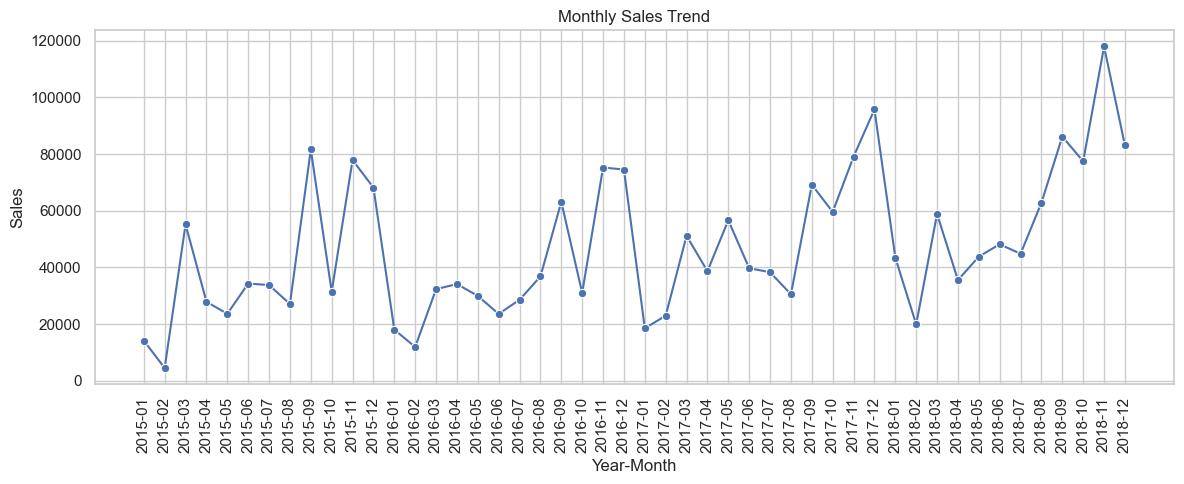

In [17]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="Year-Month", y="Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("output/monthly_sales_trend.png")
plt.show()


Sales By Region


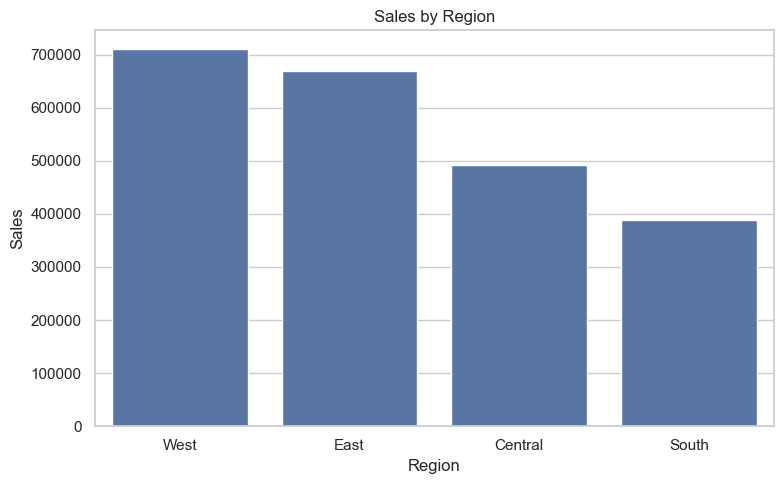

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(data=sales_by_region, x="Region", y="Sales")
plt.title("Sales by Region")
plt.tight_layout()
plt.savefig("output/sales_by_region.png")
plt.show()

Top Sub-Categories

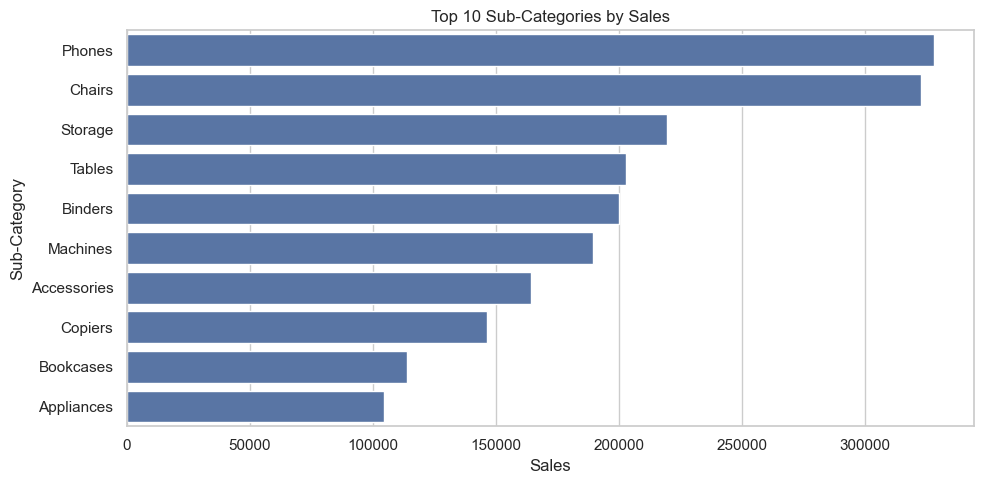

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(data=sales_by_subcategory.head(10), x="Sales", y="Sub-Category")
plt.title("Top 10 Sub-Categories by Sales")
plt.tight_layout()
plt.savefig("output/top_subcategories.png")
plt.show()

Top States

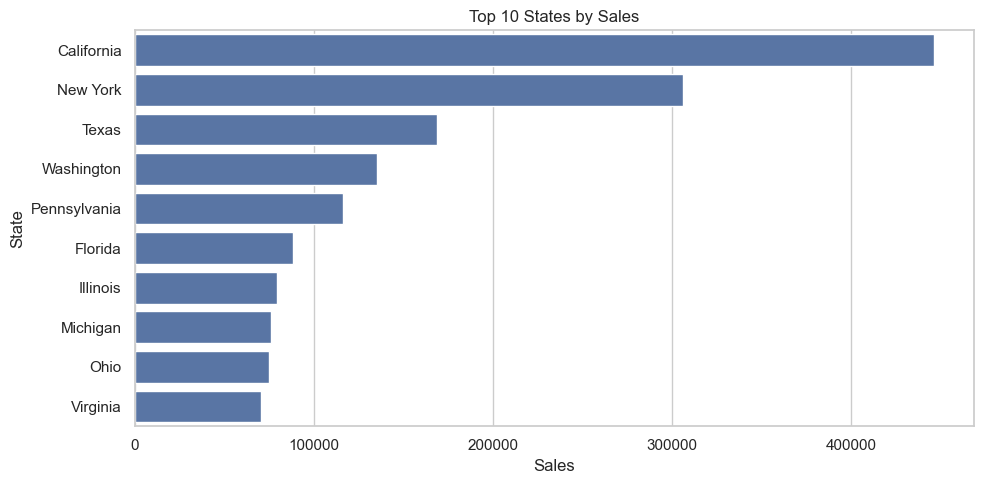

In [35]:
plt.figure(figsize=(10, 5))
sns.barplot(data=sales_by_state.head(10), x="Sales", y="State")
plt.title("Top 10 States by Sales")
plt.tight_layout()
plt.savefig("output/top_states.png")
plt.show()